In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn 
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random


In [20]:
train_data_dir="data/Training"
test_data_dir="data/Validation"


In [21]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

#training dataset loader
train_dataset = datasets.ImageFolder(
    train_data_dir,
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

#test dataset loader

val_dataset = datasets.ImageFolder(
    test_data_dir,
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [22]:
print(train_dataset)

Dataset ImageFolder
    Number of datapoints: 47009
    Root location: data/Training
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [23]:
from collections import Counter

class_counts = Counter(train_dataset.targets)
print(class_counts)

Counter({1: 23766, 0: 23243})


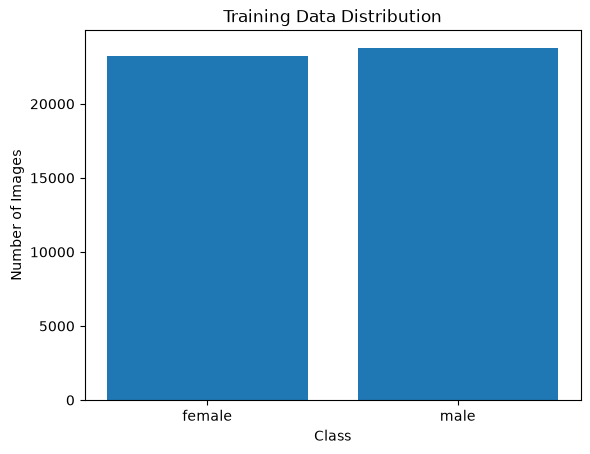

In [24]:
import matplotlib.pyplot as plt

classes = train_dataset.classes
counts = [class_counts[i] for i in range(len(classes))]

plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Data Distribution")
plt.show()

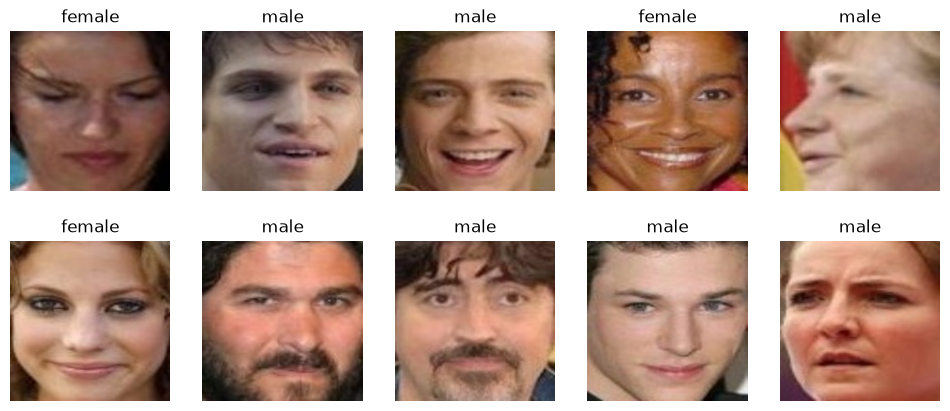

In [25]:


fig, axes = plt.subplots(2, 5, figsize=(12,5))

indices = random.sample(range(len(train_dataset)), 10)

for ax, idx in zip(axes.flatten(), indices):
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1,2,0))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.show()

In [26]:
class gender(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
             nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*28*28,512),
        nn.ReLU(),
        nn.Linear(512,2)
)
        
    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x
